In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
    
import numpy as np
import scipy
from scipy.sparse import coo_matrix, csr_matrix, csc_matrix, block_diag, identity, hstack
import matplotlib.pyplot as plt
from pyiga import assemble, bspline, vform, geometry,vis, solvers, utils, topology, algebra, quadrature, operators
#from sksparse.cholmod import cholesky
from pyiga import adaptive as adap
import itertools
import time
import statistics as st
from pyiga import algebra_cy, assemble_cy, bspline_cy

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=10)
np.set_printoptions(formatter={'float_kind':"{:.8f}".format})

In [2]:
p = 2    # spline degree
b = lambda x,y: x*(1-x)*y*(1-y)
geo=geometry.quarter_annulus()
kvs = 2 * (bspline.make_knots(p, 0.0, 1.0, 5),)

In [3]:
M = topology.MultiPatch([(kvs,geo)])

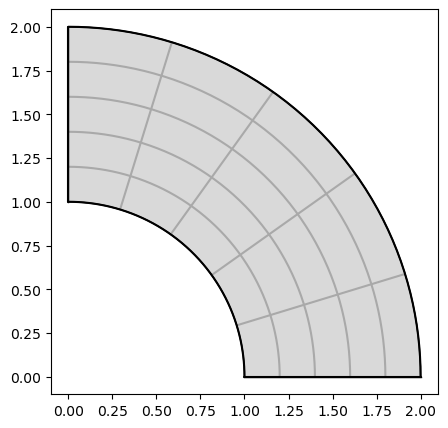

In [4]:
M.plotmesh(knots=1)

In [5]:
def make_bubble(nodes):
    """
    Build a global piecewise tensor-product bubble function
    on a tensor grid induced by `nodes`.

    Parameters
    ----------
    nodes : array_like
        Increasing nodes in [0,1]

    Returns
    -------
    b : callable
        b(x,y): evaluates the bubble function
    """
    nodes = np.asarray(nodes, dtype=float)

    if np.any(np.diff(nodes) <= 0):
        raise ValueError("nodes must be strictly increasing")
    h = np.diff(nodes)

    def phi(t):
        t = np.asarray(t)
        
        # interval index containing t
        idx = np.searchsorted(nodes, t, side='right') - 1
        
        # outside [0,1]
        valid = (idx >= 0) & (idx < len(h))
        out = np.zeros_like(t, dtype=float)
        k = idx[valid]
        xi = (t[valid] - nodes[k]) / h[k]
        out[valid] = 4*xi * (1.0 - xi)
        return out

    def b(x, y):
        return phi(x) * phi(y)

    return b

In [6]:
b = make_bubble(kvs[0].mesh)

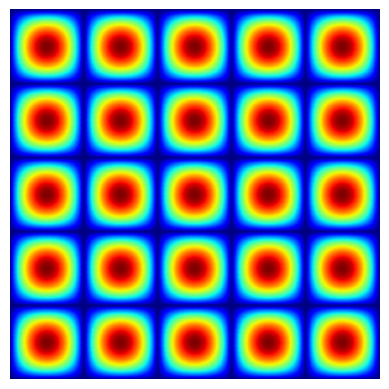

In [8]:
#M.plotmesh(knots=1)
vis.plot_field(b,geo=geometry.unit_square(),res=300, cmap='jet');
#plt.colorbar(ax=ax);
plt.axis('scaled');
plt.axis('off');
plt.savefig('/home/wolfman/Pictures/BubblesInterior.png',bbox_inches='tight',dpi=100);

In [9]:
kv = bspline.make_knots(2,0,1,5)
nodes = kv.mesh
kv1= kv.h_refine()
nodes1=kv1.mesh

h = np.diff(nodes)
def phi(t):
        t = np.asarray(t)
        
        # interval index containing t
        idx = np.searchsorted(nodes, t, side='right') - 1
        
        # outside [0,1]
        valid = (idx >= 0) & (idx < len(h))
        out = np.zeros_like(t, dtype=float)
        k = idx[valid]
        xi = (t[valid] - nodes[k]) / h[k]
        out[valid] = xi * (1.0 - xi)
        return out

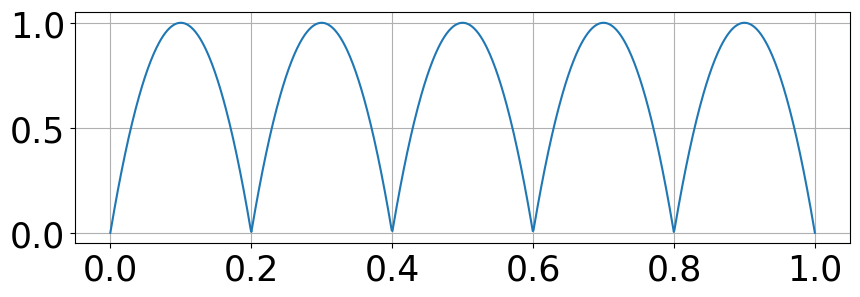

In [13]:
plt.figure(figsize=(10, 3))
x = np.linspace(0,1,1000)
plt.plot(x,4*phi(x));
#plt.axis('scaled');
plt.grid(True);
plt.yticks([0,0.5,1]);
plt.xticks(fontsize=25);
plt.yticks(fontsize=25);
plt.savefig('/home/wolfman/Pictures/BubbleEdge.pdf',bbox_inches='tight');

In [78]:
spline = bspline.BSplineFunc(kv,np.random.rand(kv.numdofs))

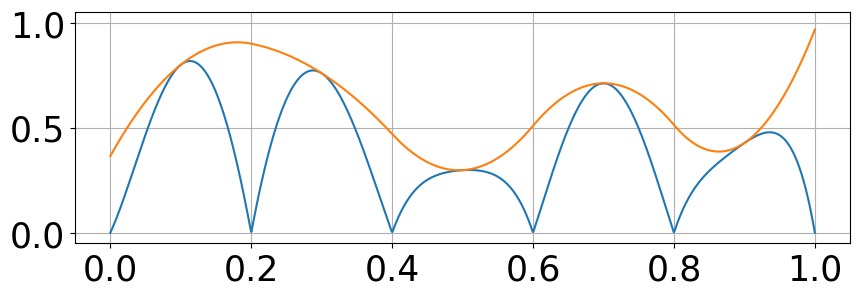

In [79]:
plt.figure(figsize=(10, 3))
x = np.linspace(0,1,1000)
plt.plot(x,4*phi(x)*spline(x))
plt.plot(x,spline(x))
plt.ylim(-0.05, 1.05);
plt.yticks([0,0.5,1]);
#plt.axis('scaled');
plt.grid(True);
plt.xticks(fontsize=25);
plt.yticks(fontsize=25);
plt.savefig('/home/wolfman/Pictures/SplineBubbleEdge.pdf',bbox_inches='tight');

In [103]:
import numpy as np

def P(n, x):
    if n == 0:
        return 1.0
    if n == 1:
        return x

    return ((2*n - 1)*x*P(n-1, x) - (n-1)*P(n-2, x)) / n


def psi(p, sd):
    if sd == 0:
        return lambda t: (1-t) * (-1)**p * P(p+2, 2*t-1)
    elif sd == 1:
        return lambda t: t * P(p+2, 2*t-1)


def make_phi(nodes, S):
    nodes = np.asarray(nodes, dtype=float)

    if np.any(np.diff(nodes) <= 0):
        raise ValueError("nodes must be strictly increasing")

    h = np.diff(nodes)

    def phi(t):
        t = np.asarray(t)

        idx = np.searchsorted(nodes, t, side='right') - 1

        valid = (idx >= 0) & (idx < len(h))
        out = np.zeros_like(t, dtype=float)

        k = idx[valid]
        xi = (t[valid] - nodes[k]) / h[k]

        out[valid] = 4 * xi * (1 - xi) * S(t[valid])

        return out

    return phi, h


def make_bubble(nodes_x, nodes_y, S, p, ax, sd):

    phi_x, h_x = make_phi(nodes_x, S)
    phi_y, h_y = make_phi(nodes_y, S)

    psi_p = psi(p, sd)

    if ax == 0:  # horizontal edge bubbles

        if sd == 0:
            def b(x, y):
                y = np.asarray(y)
                return np.where(
                    y <= h_y[0],
                    psi_p(y / h_y[0]) * phi_x(x),
                    0.0
                )

        elif sd == 1:
            def b(x, y):
                y = np.asarray(y)
                return np.where(
                    1-y <= h_y[-1],
                    psi_p((y - nodes_y[-2]) / h_y[-1]) * phi_x(x),
                    0.0
                )

    elif ax == 1:  # vertical edge bubbles

        if sd == 0:
            def b(x, y):
                x = np.asarray(x)
                return np.where(
                    x <= h_x[0],
                    psi_p(x / h_x[0]) * phi_y(y),
                    0.0
                )

        elif sd == 1:
            def b(x, y):
                x = np.asarray(x)
                return np.where(
                    1-x <= h_x[-1],
                    psi_p((x - nodes_x[-2]) / h_x[-1]) * phi_y(y),
                    0.0
                )

    return b

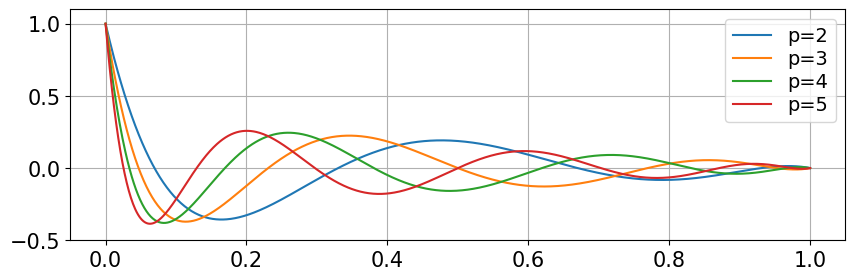

In [104]:
x = np.linspace(0,1,1001)
fig = plt.figure(figsize=(10,3))
plt.grid(True);
plt.xticks(fontsize=15);
plt.yticks(fontsize=15);
plt.ylim(-0.5, 1.1);
plt.yticks([-0.5,0,0.5,1]);
for p in range(2,6):
    psi_ = psi(p,0)
    plt.plot(x,psi_(x),label='p='+str(p))
plt.legend(
    fontsize=14,          # text size
    #frameon=True,         # show box
    #fancybox=True,        # rounded corners
    #shadow=True,          # shadow
    framealpha=0.8,       # transparency
    #borderpad=1.5,        # padding inside box
    labelspacing=0.2,     # vertical spacing
    #handlelength=3,       # line length in legend
    markerscale=1.5,       # marker size
    ncol=1
)

plt.savefig('/home/wolfman/Pictures/OrthogonalPolynomials.pdf',bbox_inches='tight');

In [105]:
b00=make_bubble(nodes,nodes,spline,2,0,0)
b01=make_bubble(nodes,nodes,spline,2,0,1)
b10=make_bubble(nodes,nodes,spline,2,1,0)
b11=make_bubble(nodes,nodes,spline,2,1,1)

x = np.linspace(0,1, 1001)
y = np.linspace(0,1, 1001)
X, Y = np.meshgrid(x, y)

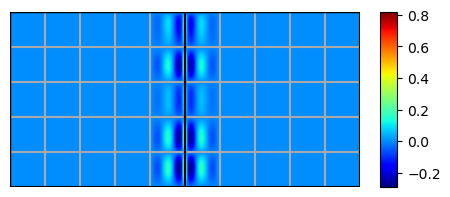

In [106]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
M_ = topology.MultiPatch([((kv,kv),geometry.unit_square()),((kv,kv),geometry.unit_square().translate((1,0)))])
fig = plt.figure(figsize=(5,5))

vis.plot_field(b11,geo=geometry.unit_square(),res=500, cmap='jet');
im,ax=vis.plot_field(b10,geo=geometry.unit_square().translate((1,0)),res=500, cmap='jet');
M_.plotmesh(knots=1,axis=plt.gca());

plt.axis('scaled');
plt.axis('off');

divider = make_axes_locatable(ax)
# vertical colorbar with same height as ax
cax = divider.append_axes("right", size="5%", pad=0.2)

cbar = fig.colorbar(im, cax=cax)

plt.savefig('/home/wolfman/Pictures/BubbleEdgeVolume.png',bbox_inches='tight',dpi=100);
plt.show()

In [107]:
geo1=geometry.quarter_annulus(2,3)
geo2=geometry.quarter_annulus(1,2)

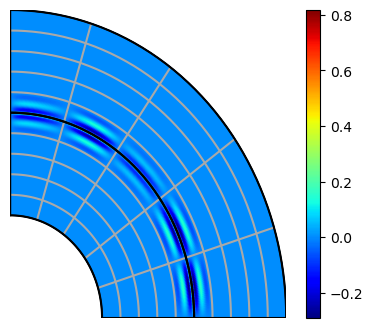

In [108]:
M = topology.MultiPatch([((kv,kv),geo1),((kv,kv),geo2)])
fig = plt.figure(figsize=(4,4))
#M.plotmesh(knots=1)
vis.plot_field(b10,geo=geo1,res=500, cmap='jet');
im,ax=vis.plot_field(b11,geo=geo2,res=500, cmap='jet');
ax.set_axis_off();
M.plotmesh(knots=1,axis=plt.gca())

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.2)

cbar = fig.colorbar(im, cax=cax)

plt.savefig('/home/wolfman/Pictures/BubbleEdgeVolumeGeo.png',bbox_inches='tight',dpi=100);
plt.show()

In [129]:
# b00=make_bubble(nodes,spline,2,0,0)
# b01=make_bubble(nodes,spline,2,0,1)
b10=make_bubble(nodes1,nodes1,spline,2,1,0)
b11=make_bubble(nodes,nodes1,spline,2,1,1)

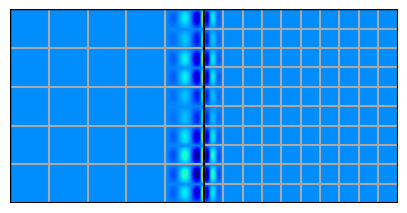

In [130]:
M_ = topology.MultiPatch([((kv,kv),geometry.unit_square()),((kv1,kv1),geometry.unit_square().translate((1,0)))])
fig = plt.figure(figsize=[5,5])

vis.plot_field(b11,geo=geometry.unit_square(),res=500, cmap='jet');
im,ax=vis.plot_field(b10,geo=geometry.unit_square().translate((1,0)),res=500, cmap='jet');
M_.plotmesh(knots=1,axis=plt.gca());

plt.axis('scaled');
plt.axis('off');

# divider = make_axes_locatable(ax)
# # vertical colorbar with same height as ax
# cax = divider.append_axes("right", size="5%", pad=0.2)

# cbar = fig.colorbar(im, cax=cax)

plt.savefig('/home/wolfman/Pictures/BubbleEdgeVolumeNonMatchingFull.png',bbox_inches='tight',dpi=100);
plt.show()

vmin, vmax = im.get_clim()

In [131]:
b10=make_bubble(nodes,nodes,lambda x: spline(x/2+0.5),2,1,0)
b11=lambda x,y: (y>0.5)*make_bubble(nodes,nodes1,spline,2,1,1)(x,y)

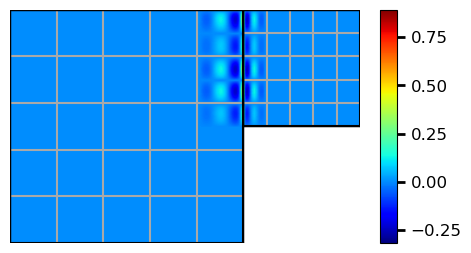

In [138]:
M_ = topology.MultiPatch([((kv,kv),geometry.unit_square()),((kv,kv),geometry.unit_square().scale(0.5).translate((1,0.5)))], autodetect=False)
fig = plt.figure(figsize=(5,5))

vis.plot_field(b11,geo=geometry.unit_square(),res=500, cmap='jet',vmin=vmin,vmax=vmax);
im,ax=vis.plot_field(b10,geo=geometry.unit_square().scale(0.5).translate((1,0.5)),res=500, cmap='jet',vmin=vmin,vmax=vmax);
M_.plotmesh(knots=1,axis=plt.gca());

plt.axis('scaled');
plt.axis('off');

divider = make_axes_locatable(ax)
# vertical colorbar with same height as ax
cax = divider.append_axes("right", size="5%", pad=0.2)

cbar = fig.colorbar(im, cax=cax)
#cbar.ax.tick_params(labelsize=16)
cbar.ax.tick_params(labelsize=12, width=2, length=6)

plt.savefig('/home/wolfman/Pictures/BubbleEdgeVolumeNonMatching.png',bbox_inches='tight',dpi=100);
plt.show()